# Interactive Script: **get_cloud_layers**

**Author:** Baturalp Arisoy<br>
**Contact:** baturalp.arisoy@uni-wuerzburg.de - Call me Batu :)

## Overview
This notebook guides the user through the essentials of _stac2cube.get_cloud_layers_ function.

## Contents

1. [How to **get_cloud_layers**](#1-how-to-get_cloud_layers)
2. [Generate Multiple Masks from Probability Map](#2-generate-multiple-masks-from-probability-map)
3. [Mask L2A Stack with Masking Layers](#3-mask-l2a-stack-with-masking-layers)
4. [Fully Automated Workflow](#4-fully-automated-workflow)
5. [Update Existing Cloud Layers](#5-update-existing-cloud-layers)

---

## Import

In [ ]:
from stac2cube import get_cloud_layers, mask_stac_clouds, mask_from_probability
import xarray as xr
import matplotlib.pyplot as plt
import numpy as np

## 1. How to **get_cloud_layers**

> **Note:**<br>
> **get_cloud_layers** cannot return lazy array because s2cloudless algorithm must be applied to computed data. Therefore, use the following cells if you are on a machine with a strong computational power.<br>  Otherwise, use HPC Slurm job and read the exported NETCDF file

### 1.1 Set the parameters

In [2]:
polygon = [74.765396,41.406943,74.999371,41.428827]
daterange = ["2024-04-01", "2024-05-01"]
output = "./results/test_cloud.nc"
threshold = [40, 50, 60, 70, 80, 90]    # Percentages of desired binary masks. If None -> returns only cloud probability maps
clip_raster = False
masking = None

### 1.2 Get Cloud Layers as exported NETCDF

In [ ]:
cloud_stac = get_cloud_layers(polygon=polygon, daterange=daterange, output=output,
                                clip_raster=clip_raster,
                                threshold=threshold, masking=masking
                            )

### 1.3 Alternative: Read the file

In [14]:
cloud_path = "./results/test_cloud.nc"

cloud = xr.open_dataset(cloud_path)
cloud_stac = cloud.Cloud_Stack

In [ ]:
cloud_stac

### 1.4 Select Cloud Layers

In [5]:
cloud_probability = cloud_stac.sel(band="cloud_prob")
cloud_mask = cloud_stac.sel(band="cloud_mask_40")

### 1.5 Plot Probability Map

In [ ]:
cloud_prob = cloud_probability.sel(time="2024-04-09")

fig, ax = plt.subplots(figsize=(20, 15))
ax.axis('off')
ax.imshow(cloud_prob, cmap='gray')

### 1.6 Plot Binary Mask Map

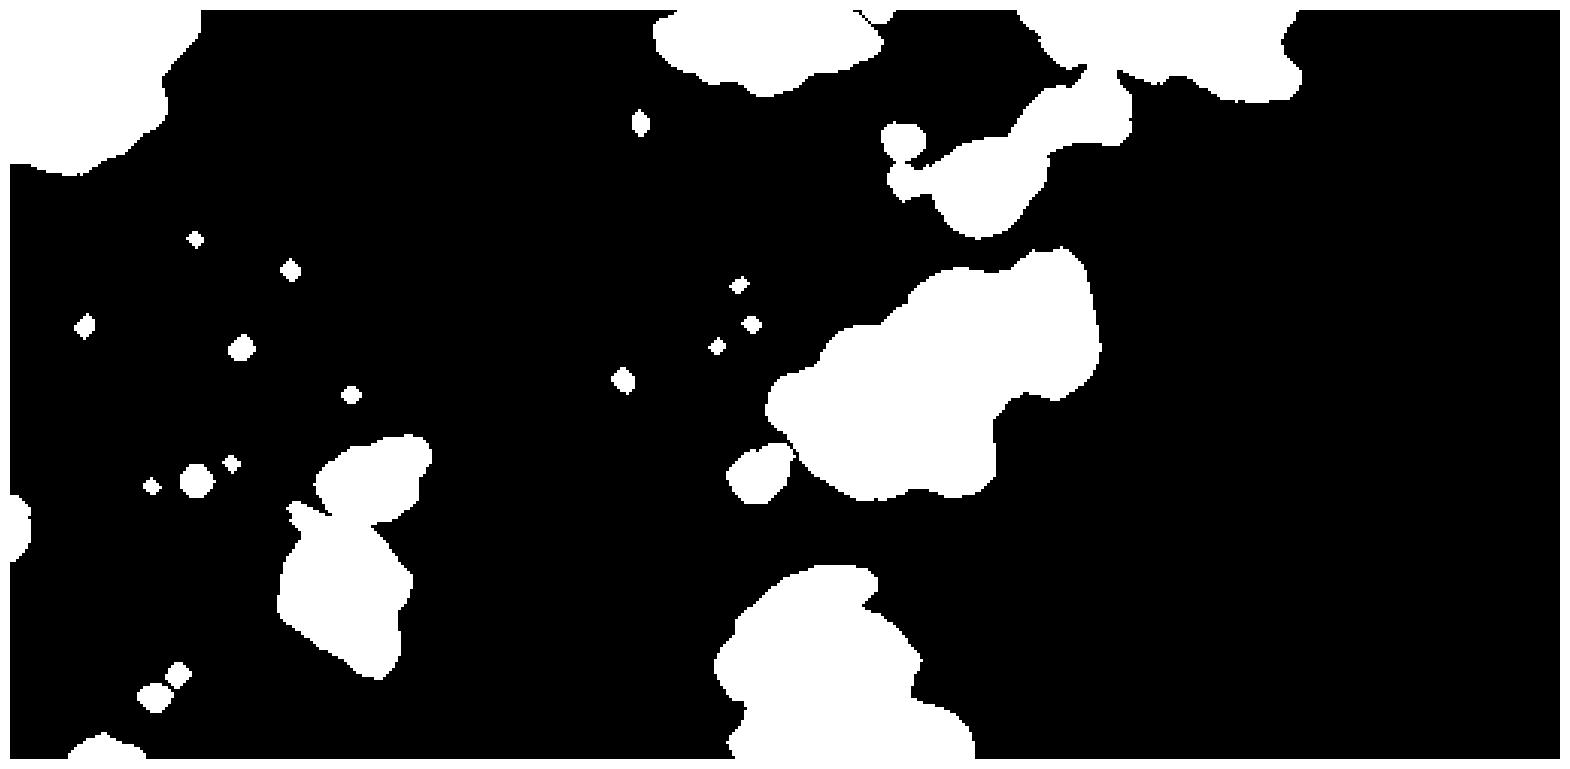

In [10]:
cloud_masking = cloud_mask.sel(time="2024-04-08")

fig, ax = plt.subplots(figsize=(20, 15))
ax.axis('off')
ax.imshow(cloud_masking, cmap='gray')

### 1.7 Compare with RGB

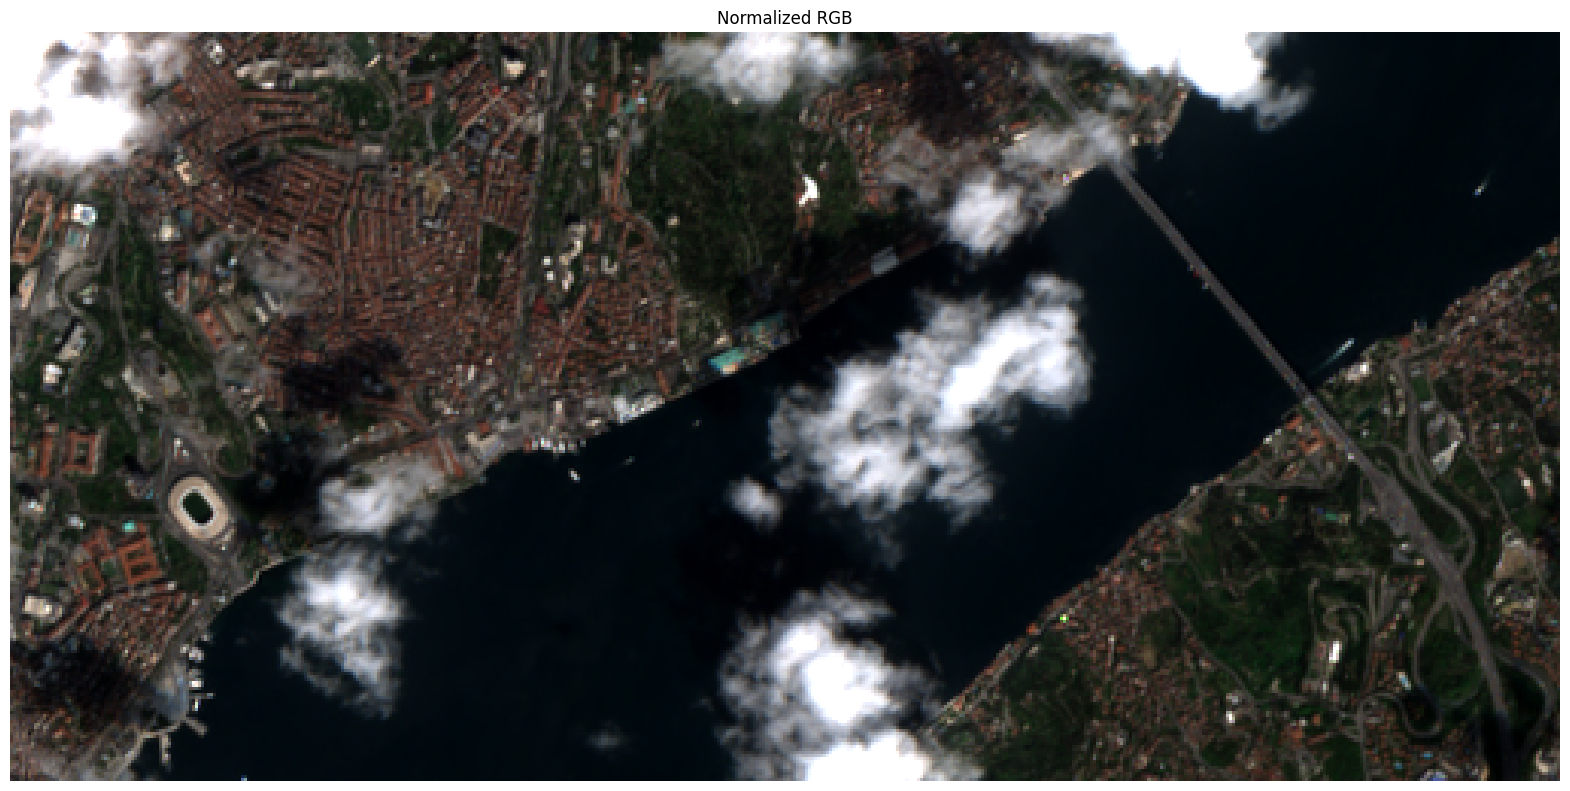

In [11]:
path = "./results/test.nc"

stac = xr.open_dataset(path)
stac = stac.Spectral_Temporal_Stack

time_to_visualize = '2024-04-08'
bands = ["red", "green", "blue"]

da_time = stac.sel(time=time_to_visualize)
da_rgb = da_time.sel(band=bands)
rgb_image = da_rgb.values.transpose(1, 2, 0)

# Remove normalization for composites other than RGB
p2 = np.percentile(rgb_image, 2)
p98 = np.percentile(rgb_image, 98)
rgb_clipped = np.clip(rgb_image, p2, p98)
rgb_normalized = (rgb_clipped - p2) / (p98 - p2)

# Plot the image
plt.figure(figsize=(20, 15))
plt.imshow(rgb_normalized)
plt.title("Normalized RGB")
plt.axis("off")
plt.show()

## 2. Generate Multiple Masks from Probability Map

In [5]:
cloud_probability = cloud_stac.sel(band="cloud_prob")

In [6]:
# The list of threshold is the list of binary masks to be generated.
# You can add two more parameters to change the shape of clouds. Default: average_over=4, dilation_size=2. according to s2cloudless documentation:
# average_over: Size of the disk in pixels for performing convolution (averaging probability over pixels).
# dilation_size: Size of the disk in pixels for performing dilation. 
    
mask_stac = mask_from_probability(cloud_probability=cloud_probability, threshold=[40, 60, 70, 90])

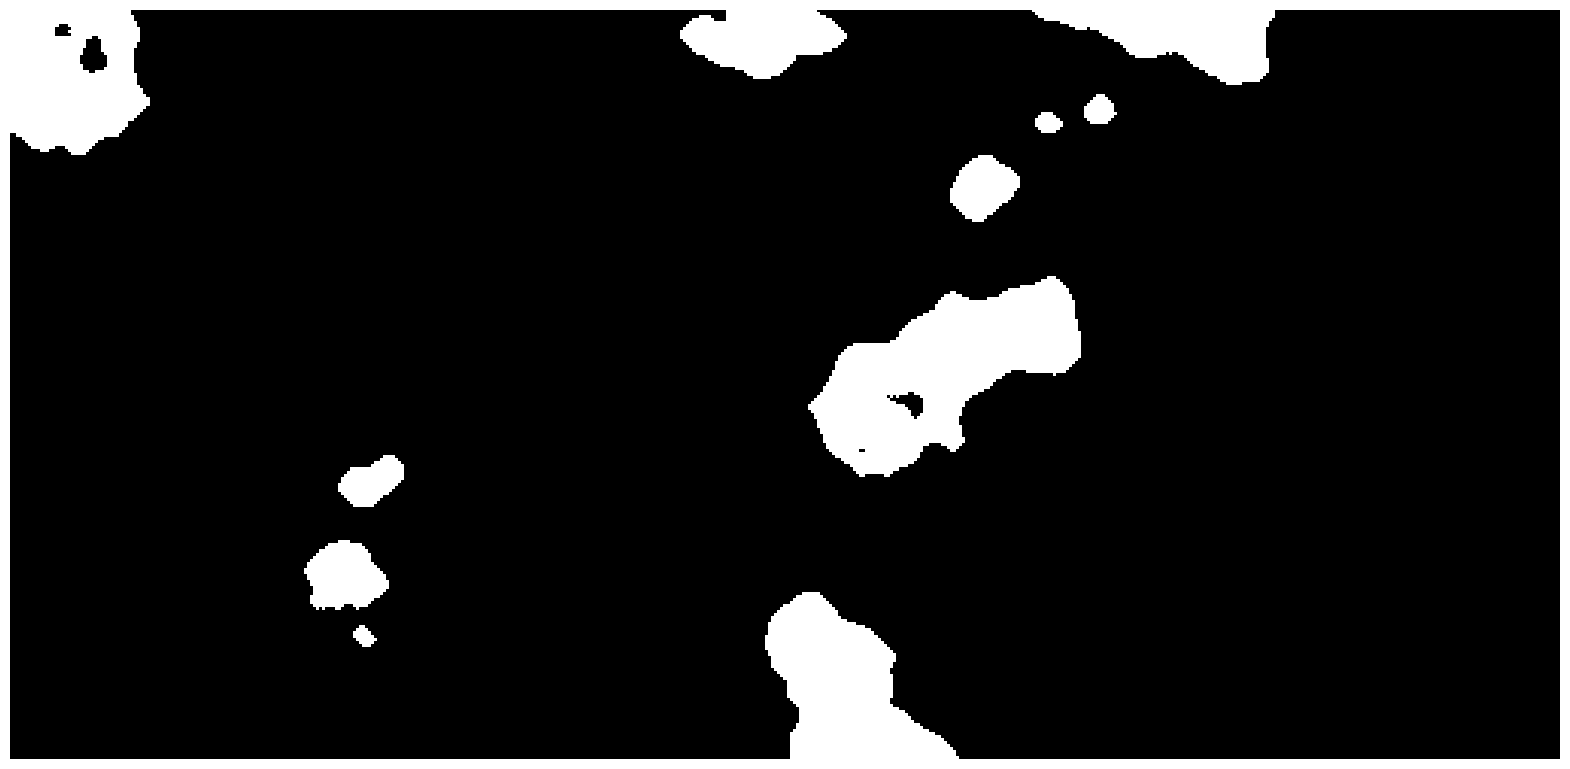

In [14]:
# Select date and mask band
mask_sliced = mask_stac.sel(time="2024-04-08")
mask_sliced = mask_sliced.sel(band="cloud_mask_90")

fig, ax = plt.subplots(figsize=(20, 15))
ax.axis('off')
ax.imshow(mask_sliced, cmap='gray')

## 3. Mask L2A Stack with Masking Layers

> **Note:**
> This could be activated when running **get_cloud_layers**. See -> *slurm/get_cloud_layers/examples.txt*

### 3.1 Read Sentinel-2 L2A Netcdf and cloud file

In [19]:
stac = xr.open_dataset("./results/test.nc")
stac = stac.Spectral_Temporal_Stack

cloud = xr.open_dataset("./results/test_cloud.nc")
cloud = cloud.Cloud_Stack

In [20]:
# Optional: Check if the dates are matching. If not, the function will fail.
def compare_times(da1, da2):
    times1 = set(da1.coords['time'].values)
    times2 = set(da2.coords['time'].values)
    missing_in_da2 = times1 - times2
    missing_in_da1 = times2 - times1
    
    if missing_in_da2:
        print("Times in first dataarray but not in second:")
        for t in sorted(missing_in_da2):
            print(t)
    else:
        print("No missing times in second dataarray from first.")
    
    if missing_in_da1:
        print("Times in second dataarray but not in first:")
        for t in sorted(missing_in_da1):
            print(t)
    else:
        print("No missing times in first dataarray from second.")

compare_times(stac, cloud)

No missing times in second dataarray from first.
No missing times in first dataarray from second.


### 3.2 Run *mask_stac_clouds*

In [ ]:
# Path for masked stac layers
output = "./results/test_masked.nc"
mask_layer = "cloud_mask_90"

masked_stac = mask_stac_clouds(stac=stac, cloud=cloud, mask_layer= mask_layer, output=output)

# can also directly input netcdf paths
# mask_stac_clouds("./results/test.nc", "./results/test_cloud.nc", "./results/test_masked.nc")

In [15]:
masked_stac = xr.open_dataset("./results/test_masked.nc")
masked_stac = masked_stac.Spectral_Temporal_Stack
masked_stac

<xarray.DataArray 'Spectral_Temporal_Stack' (time: 5, band: 6, y: 247, x: 511)> Size: 30MB
[3786510 values with dtype=float64]
Coordinates:
  * y                 (y) float64 2kB 4.547e+06 4.547e+06 ... 4.544e+06
  * x                 (x) float64 4kB 6.67e+05 6.67e+05 ... 6.721e+05 6.721e+05
  * band              (band) <U5 120B 'blue' 'green' 'red' 'nir' 'ndvi' 'ndwi'
  * time              (time) datetime64[ns] 40B 2024-04-01 ... 2024-04-11
    cloud_percentage  (time) int64 40B ...
Attributes:
    indices:         ['ndvi', 'ndwi']
    spectral_bands:  ['blue', 'green', 'red', 'nir']
    mission:         sentinel_2_l2a
    tile_id:         35TPF
    bbox:            [28.98752355 41.0315027  29.04759459 41.0525646 ]
    crs:             WGS 84 / UTM zone 35N
    transform:       [ 1.00000e+01  0.00000e+00  6.67020e+05  0.00000e+00 -1....
    grid_mapping:    spatial_ref

### 3.3 Plot Masked STAC

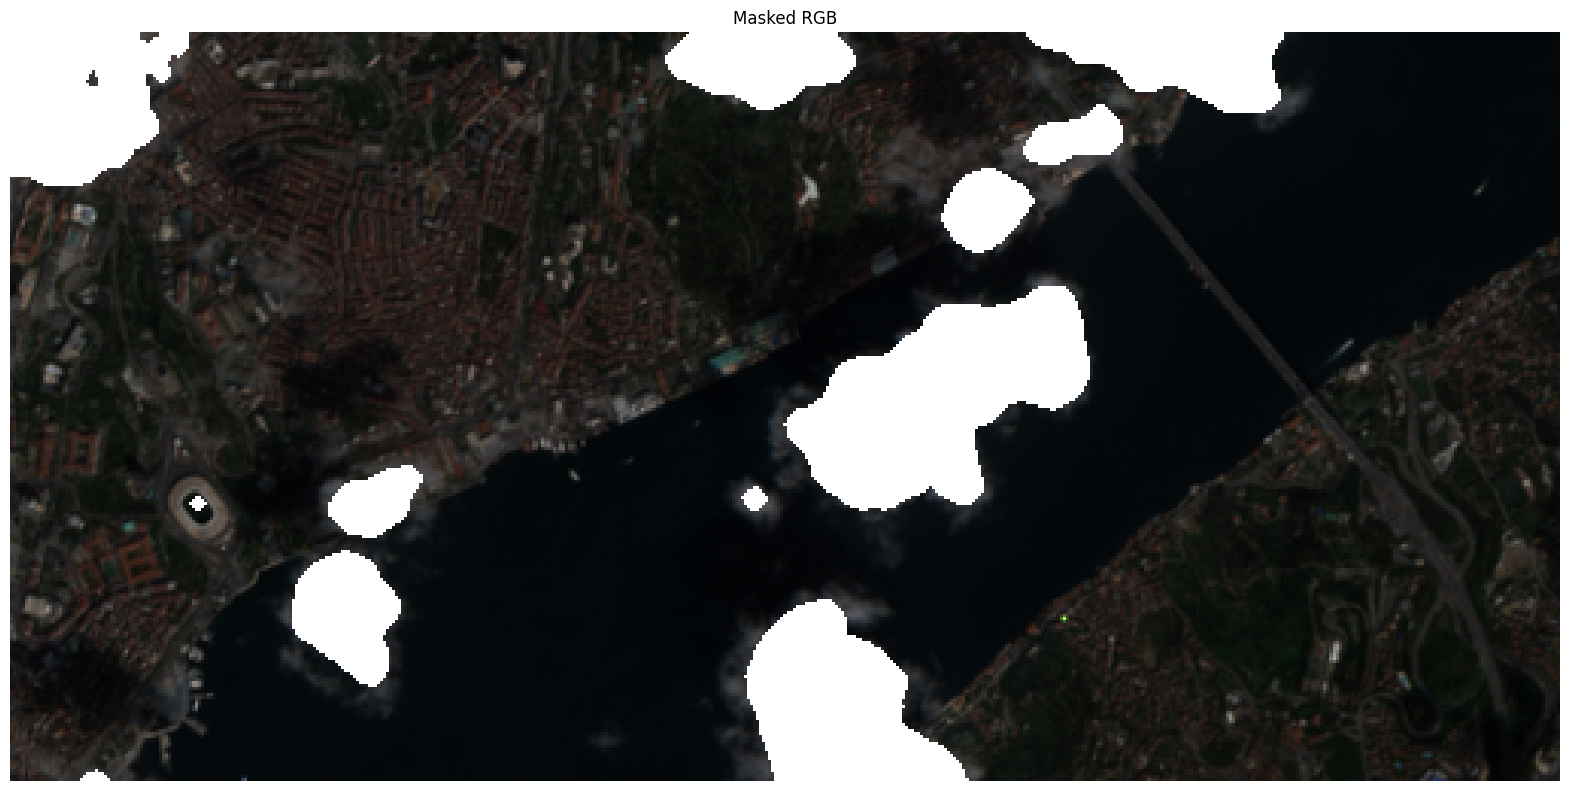

In [16]:
time_to_visualize = '2024-04-08'
bands = ["red", "green", "blue"]

da_time = masked_stac.sel(time=time_to_visualize)
da_rgb = da_time.sel(band=bands)
rgb_image = da_rgb.values.transpose(1, 2, 0)

# Plot the image
plt.figure(figsize=(20, 15))
plt.imshow(rgb_image)
plt.title("Masked RGB")
plt.axis("off")
plt.show()

- 71 items for query of get_stac_layers -> max_cc = 100
- 23 items for query of get_stac_layers -> max_cc = 10 
- 41 items for after using s2cloudless -> max_cloud = 10

Limiting max_cc parameter of get_stac_layers function disregards 18 meaningful scenes! Therefore, keep max_cc at 100% and apply s2cloudless masking to keep the max amount of meaningful scenes.

### 3.4 Cloud Percentage of the Scene

#### 3.4.1 Request cloud percentage of the scene

In [17]:
date = '2024-04-08'

masked_stac_sliced = masked_stac.sel(time=date)
cloud_percentage = masked_stac_sliced.cloud_percentage.values
print(f"Cloud Coverage Percentage on {date}: {cloud_percentage}%")

Cloud Coverage Percentage on 2024-04-08: 11%


#### 3.4.2 Cloud Filtering

> **Note:**
> Unlike stac query of max_cc (entire S2 tile), following cloud percentage represents the cloud coverage of the actual scene.

**Select scenes with less than max cloud coverage percentage**

In [18]:
stac = xr.open_dataset("./results/test_masked.nc")
masked_stac = stac.Spectral_Temporal_Stack
masked_stac

<xarray.DataArray 'Spectral_Temporal_Stack' (time: 71, band: 6, y: 470, x: 1277)> Size: 2GB
[255680940 values with dtype=float64]
Coordinates:
  * y                 (y) float64 4kB 4.583e+06 4.583e+06 ... 4.578e+06
  * x                 (x) float64 10kB 5.344e+05 5.344e+05 ... 5.471e+05
  * band              (band) <U5 120B 'blue' 'green' 'red' 'nir' 'ndvi' 'ndwi'
  * time              (time) datetime64[ns] 568B 2024-01-05 ... 2024-12-30
    cloud_percentage  (time) int64 568B ...
Attributes:
    crs:           WGS 84 / UTM zone 43N
    transform:     [ 1.00000e+01  0.00000e+00  5.34360e+05  0.00000e+00 -1.00...
    grid_mapping:  spatial_ref

In [ ]:
max_cloud = 10

filtered_data = masked_stac.where(masked_stac.cloud_percentage <= max_cloud, drop=True)
filtered_data

## 4. Fully Automated Workflow

> **Note:**
> - Below workflow calculates cloud layers for dates of L2A dataset.
> - Exports cloud layers dataset to desired path. 
> - Applies binary mask of the desired percentage.
> - Exports masked L2A dataset in the same folder. 

In [2]:
masking = "./results/test.nc"                   # Path to image to be masked. The masked image will be exported in the same folder with extra prefix "_masked"
output = "./results/test_cloud.nc"              # Output of cloud layers, not masked image.
threshold = 70                                  # Percentage of the desired binary masks. Can't be a list. Can be any number between 0-100.

In [ ]:
get_cloud_layers(masking=masking, 
                    output=output, 
                    threshold=threshold
                )

## 5. Update Existing Cloud Layers

> **Warning:**
> Always run one of the options below, not both of them in a single run! Updating mechanism alters the original files and causes problem when the other option is executed.<br> <br>
> Once the updating mechanism is triggered, the other option won't be effective until new dates are ingested.

### 5.1 Update Only Cloud Layers

In [19]:
img = ("./results/test_cloud.nc")
dataset = xr.open_dataset(img)
stac = dataset.Cloud_Stack
stac.time.values

array(['2024-04-01T00:00:00.000000000', '2024-04-03T00:00:00.000000000',
       '2024-04-06T00:00:00.000000000', '2024-04-08T00:00:00.000000000',
       '2024-04-11T00:00:00.000000000'], dtype='datetime64[ns]')

In [20]:
update = "./results/test_cloud.nc"
daterange = ["2024-04-04", "2024-04-15"]
threshold = [70, 80, 90]    # Percentages of desired binary masks. If None -> returns only cloud probability maps
clip_raster = False # does not work for now

In [21]:
cloud_stac = get_cloud_layers(update=update, daterange=daterange,
                                clip_raster=clip_raster, threshold=threshold
                            )

1 new date found!
Processed time slice: 1/1 (time: 2024-04-13T00:00:00.000000000)
Export is done: ./results/test_cloud.nc


In [ ]:
cloud_stac

In [12]:
cloud_stac.time.values

array(['2024-04-01T00:00:00.000000000', '2024-04-03T00:00:00.000000000',
       '2024-04-06T00:00:00.000000000', '2024-04-08T00:00:00.000000000',
       '2024-04-11T00:00:00.000000000', '2024-04-13T00:00:00.000000000'],
      dtype='datetime64[ns]')

### 5.2 Update Cloud Layers and Masked L2A

In [5]:
stac_before = "./results/test_masked70.nc"

stac_before = xr.open_dataset(stac_before)
stac_before = stac_before.Spectral_Temporal_Stack
stac_before.time.values

array(['2024-04-06T00:00:00.000000000', '2024-04-08T00:00:00.000000000',
       '2024-04-11T00:00:00.000000000'], dtype='datetime64[ns]')

In [6]:
update = "./results/test_cloud.nc"
masking = "./results/test.nc"
threshold = 70                        # Percentage of the desired binary masks. Can't be a list. Can be any number between 0-100.

In [7]:
updated_mask= get_cloud_layers(update=update, masking=masking, threshold=threshold)

1 new date found!
Processed time slice: 1/1 (time: 2024-04-11T00:00:00.000000000)
Export is done: ./results/test_cloud.nc
Export is done: ./results/test_masked70.nc


In [ ]:
stac_after = "./results/test_masked70.nc"

stac_after = xr.open_dataset(stac_after)
stac_after = stac_after.Spectral_Temporal_Stack
stac_after.time.values